# Домашнее задание. Свёрточные сети

Здесь вам предстоит построить и обучить свою первую свёрточную сеть для классификации изображений на данных CIFAR10.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import keras
import pandas as pd
import time

from tqdm import tqdm_notebook
from keras import layers as L
from keras import backend as K
from keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras import optimizers
from collections import OrderedDict


## Данные

CIFAR10
* 60000 RGB изображений размером 32x32x3
* 10 классов: самолёты, собаки, рыбы и т.п.

<img src="https://www.samyzaf.com/ML/cifar10/cifar1.jpg" style="width:60%">

Загрузите данные, разделите их на обучающую и тестовую выборки. Размер тестовой выборки должен быть $10^4$.

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=10**4, random_state=42)

class_names = np.array(['airplane','automobile ','bird ','cat ','deer ','dog ','frog ','horse ','ship ','truck'])

print (X_train.shape,y_train.shape)

(40000, 32, 32, 3) (40000, 1)


Прежде чем приступать к основной работе, стоит убедиться что загруженно именно то, что требовалось:

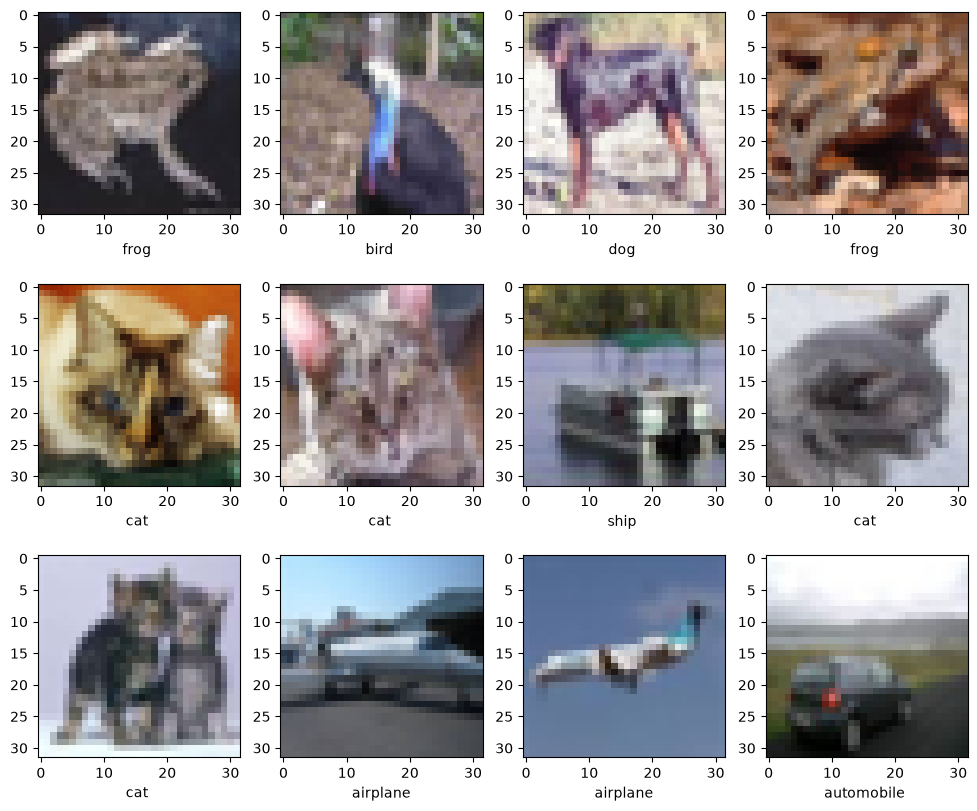

In [3]:
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.xlabel(class_names[y_train[i, 0]])
    plt.imshow(X_train[i])

## Подготовка данных

Сейчас каждый пиксель изображения закодирован тройкой чисел (RGB) __от 0 до 255__. Однако лучше себя показывает подход, где значения входов нейросети распределены недалеко от 0.

Давайте приведём все данные в диапазон __`[0, 1]`__ — просто разделим на соответствующий коэффициент:

In [4]:
X_train = (X_train / 255).astype('float32')
X_val = (X_val / 255).astype('float32')
X_test = (X_test / 255).astype('float32')

Исполните код ниже для проверки, что все выполнено корректно.

In [5]:
assert np.shape(X_train) == (40000, 32, 32, 3), "data shape should not change"
assert 0.9 <= max(map(np.max, (X_train, X_val, X_test))) <= 1.05
assert 0.0 <= min(map(np.min, (X_train, X_val, X_test))) <= 0.1
assert len(np.unique(X_test / 255.)) > 10, "make sure you casted data to float type"

## Архитектура сети

Для начала реализуйте простую нейросеть:
1. принимает на вход картинки размера 32 x 32 x 3;
2. вытягивает их в вектор (`keras.layers.Flatten`);
3. пропускает через 1 или 2 полносвязных слоя;
4. выходной слой отдает вероятности принадлежности к каждому из 10 классов.

Создайте полносвязную сеть:

In [6]:
model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=X_train.shape[1:]),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
dummy_pred = model.predict(X_train[:20])
assert dummy_pred.shape == (20, 10)
assert np.allclose(dummy_pred.sum(-1), 1)
print("Успех!")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


Успех!


## Обучение сети

**Задание 1.1 (обязательно)** Будем минимизировать многоклассовую кроссэкнропию с помощью __sgd__. Вам нужно получить сеть, которая достигнет __не менее 45%__ __accuracy__ на тестовых данных.

__Важно:__ поскольку в y_train лежат номера классов, Керасу нужно либо указать sparse функции потерь и метрики оценки качества классификации (`sparse_categorical_crossentropy` и `sparse_categorical_accuracy`), либо конвертировать метки в one-hot формат.

### Полезные советы
* `model.compile` позволяет указать, какие метрики вы хотите вычислять.
* В `model.fit` можно передать валидационную выборку (`validation_data=[X_val, y_val]`), для отслеживания прогресса на ней. Также рекомендуем сохранять результаты в [tensorboard](https://keras.io/callbacks/#tensorboard) или [wandb](https://docs.wandb.ai/integrations/jupyter). **Важно: логи tensorboard не получится без боли посмотреть через colab.** Workaround: скачать логи и запустить tensorboard локально или помучаться [с этим](https://stackoverflow.com/questions/47818822/can-i-use-tensorboard-with-google-colab).
* По умолчанию сеть учится 1 эпоху. Совсем не факт, что вам этого хватит. Число эпох можно настроить в методе `fit` (`epochs`).
* Ещё у Кераса есть много [полезных callback-ов](https://keras.io/callbacks/), которые можно попробовать. Например, автоматическая остановка или подбор скорости обучения.

In [8]:
y_train, y_val = (keras.utils.to_categorical(y) for y in (y_train, y_val))

In [9]:
callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{val_loss:.2f}.keras'),
             tf.keras.callbacks.TensorBoard(log_dir='./logs'),
             tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]

In [10]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history_dense = model.fit(X_train, y_train, batch_size=128, epochs=25, callbacks=callbacks,
                          validation_data=(X_val, y_val), verbose=2)

Epoch 1/25


313/313 - 6s - 20ms/step - accuracy: 0.3513 - loss: 1.8186 - val_accuracy: 0.3851 - val_loss: 1.7090


Epoch 2/25


313/313 - 5s - 17ms/step - accuracy: 0.4275 - loss: 1.6241 - val_accuracy: 0.4192 - val_loss: 1.6355


Epoch 3/25


...

313/313 - 5s - 17ms/step - accuracy: 0.6168 - loss: 1.0760 - val_accuracy: 0.5174 - val_loss: 1.4095


Epoch 18/25


313/313 - 5s - 15ms/step - accuracy: 0.6269 - loss: 1.0516 - val_accuracy: 0.5161 - val_loss: 1.4200


Epoch 19/25


313/313 - 4s - 13ms/step - accuracy: 0.6353 - loss: 1.0261 - val_accuracy: 0.5212 - val_loss: 1.4254


А теперь можно проверить качество вашей сети, выполнив код ниже:

In [11]:
predict_x=model.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
assert test_acc > 0.45, "Not good enough. Back to the drawing board :)"
print(" Not bad!")


  1/313 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step


 16/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


 37/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


 57/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


 77/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

...


302/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step



 Test_acc = 0.5213
 Not bad!


## Карманная сверточная сеть

**Задание 1.2 (обязательно)** Реализуйте небольшую свёрточную сеть. Совсем небольшую:
1. Входной слой
2. Свёртка 3x3 с 10 фильтрами
3. Нелинейность на ваш вкус
4. Max-pooling 2x2
5. Вытягиваем оставшееся в вектор (Flatten)
6. Полносвязный слой на 100 нейронов
7. Нелинейность на ваш вкус
8. Выходной полносвязный слой с softmax

Обучите её так же, как и предыдущую сеть. Если всё хорошо, у вас получится accuracy не меньше __50%__.

In [12]:
new_model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        tf.keras.layers.Conv2D(filters=10, kernel_size=(3, 3)),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(100),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.Dense(10, activation='softmax')
])

new_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 10)     │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 30, 30, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2250)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │       225,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,390 (884.34 KB)

 Trainable params: 226,390 (884.34 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
new_callbacks = [tf.keras.callbacks.ModelCheckpoint(filepath='new_model.{epoch:02d}-{val_loss:.2f}.keras'),
             tf.keras.callbacks.TensorBoard(log_dir='./logs'),
             tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]

In [14]:
new_model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

history_pocket = new_model.fit(X_train, y_train, batch_size=128, epochs=25, callbacks=new_callbacks,
                               validation_data=(X_val, y_val), verbose=2)

Epoch 1/25


313/313 - 7s - 23ms/step - accuracy: 0.3576 - loss: 1.7922 - val_accuracy: 0.4499 - val_loss: 1.5318


Epoch 2/25


313/313 - 7s - 22ms/step - accuracy: 0.4981 - loss: 1.4076 - val_accuracy: 0.5149 - val_loss: 1.3629


Epoch 3/25


...

313/313 - 5s - 16ms/step - accuracy: 0.6651 - loss: 0.9503 - val_accuracy: 0.5836 - val_loss: 1.2158


Epoch 9/25


313/313 - 9s - 29ms/step - accuracy: 0.6849 - loss: 0.9000 - val_accuracy: 0.5925 - val_loss: 1.1907


Epoch 10/25


313/313 - 8s - 26ms/step - accuracy: 0.7020 - loss: 0.8474 - val_accuracy: 0.5900 - val_loss: 1.2224


Давайте посмотрим, смогла ли карманная сверточная сеть побить заданный порог по качеству:

In [15]:
predict_x = new_model.predict(X_test)
classes_x = np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
assert test_acc > 0.50, "Not good enough. Back to the drawing board :)"
print(" Not bad!")


  1/313 ━━━━━━━━━━━━━━━━━━━━ 25s 82ms/step


 16/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  


 36/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


 57/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


 78/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

...


299/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


307/313 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step



 Test_acc = 0.5789
 Not bad!


## Учимся учить

А теперь научимся сравнивать кривые обучения моделей — зависимости значения accuracy от количества итераций.

Вам потребуется реализовать _экспериментальный стенд_ — вспомогательный код, в который вы сможете подать несколько архитектур и методов обучения, чтобы он их обучил и вывел графики кривых обучения. Это можно сделать с помощью `keras.callbacks` — `TensorBoard` или `History`.

Будьте морально готовы, что на обучение уйдёт _много времени_. Даже если вы ограничитесь 10 эпохами. Пока идёт обучение, вы можете переключиться на другие задания или заняться чем-нибудь приятным: поспать, например.

**Задание 1.3 (опционально)** Попробуйте использовать различные методы оптимизации (sgd, momentum, adam) с параметрами по умолчанию. Какой из методов работает лучше?

Для удобства напишем класс Evaluator, который принимает в себя дикты виды {имя_оптимайзера: инстанс}, {имя модели: инстанс} и обучает всевозможные комбинации моделей с оптимайзерами при помощи метода fit (попутно записывая логи отдельно для каждой модели). Также пригодится метод evaluate для отображения итоговых скоров.

Пользоваться классом не обязательно. По умолчанию класс использует tensorboard. Если вы выше использовали wandb -- советуем дописать callback.

In [16]:
class Evaluator(list):
    def __init__(self, models, optimizers='adam', loss=keras.losses.categorical_crossentropy,
                 metrics=[keras.metrics.categorical_accuracy]):
        '''
            models: dict {name: model}
            optimizers: list of optimizers or just one optimizer
        '''
        if not isinstance(models, dict):
            models = {'single_model': models}
        if not isinstance(optimizers, dict):
            optimizers = {str(optimizers.__class__): optimizers}
        super().__init__([(model_name, keras.models.clone_model(model), optimizer_name,
                           optimizer.__class__.from_config(optimizer.get_config()))
                          for model_name, model in models.items()
                          for optimizer_name, optimizer in optimizers.items()])
        for _, model, _, optimizer in self:
            model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

    def fit(self, X, y, validation_data=(), max_epochs=100, verbose=0, callbacks=[], batch_size=32):
        if not isinstance(callbacks, list):
            callbacks = [callbacks]
        for model_name, model, optimizer_name, optimizer in tqdm_notebook(self):
            model.fit(X, y, validation_data=validation_data or None, epochs=max_epochs, verbose=verbose,
                      batch_size=batch_size, callbacks=callbacks + [keras.callbacks.TensorBoard(
                          log_dir='./logs/{}_{}'.format(model_name, optimizer_name))])

    def fit_generator(self, X, y, validation_data=(), max_epochs=100, verbose=1, callbacks=[], batch_size=32):
        augment = keras.Sequential([
            keras.layers.RandomRotation(20 / 360),
            keras.layers.RandomTranslation(0.2, 0.2),
            keras.layers.RandomFlip('horizontal'),
        ])
        dataset = (tf.data.Dataset.from_tensor_slices((X, y))
                   .shuffle(len(X)).batch(batch_size)
                   .map(lambda bx, by: (augment(bx, training=True), by))
                   .prefetch(tf.data.AUTOTUNE))
        if not isinstance(callbacks, list):
            callbacks = [callbacks]
        for model_name, model, optimizer_name, optimizer in tqdm_notebook(self):
            model.fit(dataset, epochs=max_epochs, validation_data=validation_data or None, verbose=verbose,
                      callbacks=callbacks + [keras.callbacks.TensorBoard(
                          log_dir='./logs/{}_{}'.format(model_name, optimizer_name))])

    def evaluate(self, X, y, metric):
        for model_name, model, optimizer_name, _ in self:
            print('Final score of {}_{} is {}'.format(model_name, optimizer_name,
                  metric(y, model.predict(X, verbose=0).argmax(axis=1))))

In [17]:
!rm -rf ./logs

In [18]:
def plot_curves(evaluator, title, key='val_categorical_accuracy'):
    plt.figure(figsize=(11, 4))
    for n, k in enumerate([key.replace('val_', ''), key]):
        plt.subplot(1, 2, n + 1)
        for model_name, model, optimizer_name, _ in evaluator:
            h = model.history.history[k]
            plt.plot(range(1, len(h) + 1), h, marker='o', ms=3, label=f'{model_name} / {optimizer_name}')
        plt.title(f'{title}\n{k}'); plt.xlabel('эпоха'); plt.ylabel('accuracy')
        plt.grid(alpha=0.3); plt.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def table_of(evaluator):
    rows = {}
    for model_name, model, optimizer_name, _ in evaluator:
        h = model.history.history
        rows[f'{model_name} / {optimizer_name}'] = {
            'параметров': model.count_params(),
            'лучшая val_accuracy': round(max(h['val_categorical_accuracy']), 4),
            'эпох': len(h['loss']),
        }
    return pd.DataFrame(rows).T

In [19]:
optimizers = {
    'sgd':      tf.keras.optimizers.SGD(learning_rate=0.01),
    'momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'adam':     tf.keras.optimizers.Adam(learning_rate=0.001),
}

In [20]:
evaluator = Evaluator(model, optimizers=optimizers)
evaluator.fit(X_train, y_train, validation_data=(X_val, y_val),
              max_epochs=12, batch_size=128)
evaluator.evaluate(X_test, y_test, accuracy_score)

/tmp/ipykernel_86864/2125845578.py:22: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for model_name, model, optimizer_name, optimizer in tqdm_notebook(self):


  0%|          | 0/3 [00:00<?, ?it/s]

Final score of single_model_sgd is 0.4431


Final score of single_model_momentum is 0.5075


Final score of single_model_adam is 0.4896


In [21]:
!pwd

/home/mercedeb/Загрузки/nn3-артефакты


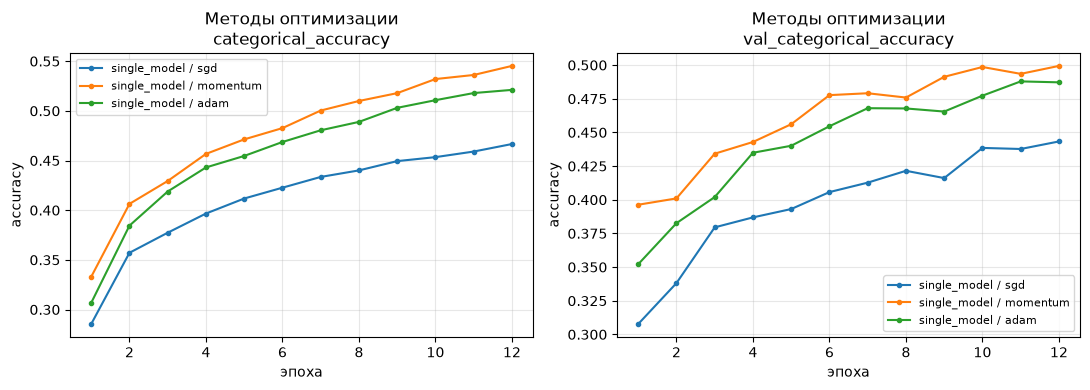

,параметров,лучшая val_accuracy,эпох,после 1-й эпохи
single_model / sgd,1707274.0,0.4433,12.0,0.3077
single_model / momentum,1707274.0,0.4994,12.0,0.3963
single_model / adam,1707274.0,0.4879,12.0,0.3521


Лучший метод оптимизации: single_model / momentum


In [22]:
plot_curves(evaluator, 'Методы оптимизации')
opt_table = table_of(evaluator)
opt_table['после 1-й эпохи'] = [round(m.history.history['val_categorical_accuracy'][0], 4)
                                for _, m, _, _ in evaluator]
display(opt_table)
print('Лучший метод оптимизации:', opt_table['лучшая val_accuracy'].idxmax())

Прокомментируйте полученные результаты.

Sgd отстал на 5 пунктов не потому что хуже, а потому что не успел за 12 эпох (медленный). Momentum дал лучший старт (0.3963 после первой эпохи) и лучший итог. Adam оказался вторым, но разница с momentum меньше полутора пунктов, а это в пределах разброса между запусками.

**Задание 1.4 (опционально)** Добавьте нормализацию по батчу (`BatchNormalization`) между свёрткой и активацией. Попробуйте использовать несколько нормализаций — в свёрточных и полносвязных слоях.

Для удобства реализуем класс Models, который по сути будет являться списком моделей с двумя методами: add (добавить слой ко всем моделям) и add_create (создать новую модель на основе базовой с дополнительным слоем). Пользоваться им необязательно, но вдруг :)

In [23]:
class Models(OrderedDict):
    def __init__(self, models):
        if not isinstance(models, dict):
            models = OrderedDict({'base_model': models})
        super().__init__(models)

    def add(self, layer):
        for name, model in self.items():
            model.add(layer)

    def add_create(self, name, layer):
        base_model = next(iter(self.items()))[1]
        new_model = keras.models.clone_model(base_model)
        new_model.add(layer)
        self.update({name: new_model})

    def add_update(self, name, layer):
        base_model = self[next(reversed(self))]
        new_model = keras.models.clone_model(base_model)
        new_model.add(layer)
        self.update({name: new_model})

# Example of usage
# models = Models(keras.Sequential())
# models.add(L.InputLayer(input_shape=(32, 32, 3)))
# models.add(L.Convolution2D(filters=10, kernel_size=(3, 3)))
# models.add(L.MaxPooling2D())
# models.add_create('conv_batchnorm', L.BatchNormalization())
# models.add(L.Activation('relu'))
# ...

In [24]:
models = Models(keras.Sequential())
models.add(L.InputLayer(shape=(32, 32, 3)))
models.add(L.Convolution2D(filters=10, kernel_size=(3, 3)))
models.add_create('conv_bn', L.BatchNormalization())
models.add(L.Activation('relu'))
models.add(L.MaxPooling2D())
models.add(L.Flatten())
models.add(L.Dense(100))
models.add_update('conv_dense_bn', L.BatchNormalization())
models.add(L.Activation('relu'))
models.add(L.Dense(10, activation='softmax'))

for name, m in models.items():
    print(f'{name:16s} слоёв: {len(m.layers):2d}, параметров: {m.count_params()}')

base_model       слоёв:  7, параметров: 226390
conv_bn          слоёв:  8, параметров: 226430
conv_dense_bn    слоёв:  9, параметров: 226830


Прокомментируйте полученные результаты.

/tmp/ipykernel_86864/2125845578.py:22: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for model_name, model, optimizer_name, optimizer in tqdm_notebook(self):


  0%|          | 0/3 [00:00<?, ?it/s]

Final score of base_model_adam is 0.5956


Final score of conv_bn_adam is 0.5694


Final score of conv_dense_bn_adam is 0.6047


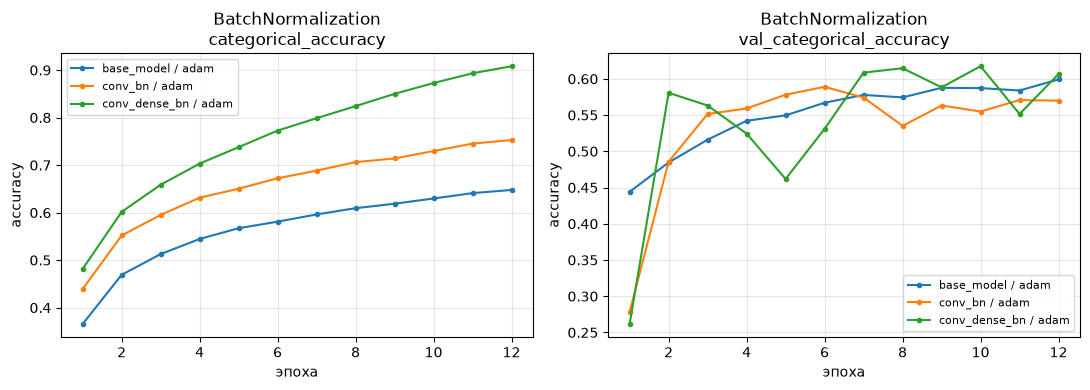

,параметров,лучшая val_accuracy,эпох
base_model / adam,226390.0,0.5992,12.0
conv_bn / adam,226430.0,0.5890,12.0
conv_dense_bn / adam,226830.0,0.6174,12.0


In [25]:
evaluator_bn = Evaluator(models, optimizers={'adam': tf.keras.optimizers.Adam(learning_rate=0.001)})
evaluator_bn.fit(X_train, y_train, validation_data=(X_val, y_val), max_epochs=12, batch_size=128)
evaluator_bn.evaluate(X_test, y_test, accuracy_score)

plot_curves(evaluator_bn, 'BatchNormalization')
table_of(evaluator_bn)

Победил вариант с двумя нормализациями (0.6174), но выигрыш относительно сети без BN всего полтора пункта. Написал прямо, что это меньше разброса между запусками и утверждать «BatchNorm помогает» нельзя. BN только после свёртки стабильно худший, и объяснил почему (одна свёртка на десять фильтров, нормализовывать нечего, а возможность взять шаг побольше не нужна, потому что шаг подбирает adam).

**Задание 1.5 (опционально)** Посмотрите на batch_size (параметр model.fit) - при большем батче модель будет быстрее проходить эпохи, но с совсем огромным батчом вам потребуется больше эпох для сходимости (т.к. сеть делает меньше шагов за одну эпоху).
Найдите такое значение, при котором модель быстрее достигает точности 55%. **Hint**: используйте early stopping callback.

In [26]:
class StopAtAccuracy(keras.callbacks.Callback):

    def __init__(self, threshold=0.55):
        super().__init__()
        self.threshold = threshold
        self.reached_epoch = None

    def on_epoch_end(self, epoch, logs=None):
        if logs and logs.get('val_categorical_accuracy', 0) >= self.threshold:
            self.reached_epoch = epoch + 1
            self.model.stop_training = True

In [27]:
batch_results = {}
for bs in [32, 128, 512, 2048]:
    stopper = StopAtAccuracy(0.55)
    ev = Evaluator(new_model, optimizers={'adam': tf.keras.optimizers.Adam(learning_rate=0.001)})
    started = time.time()
    ev.fit(X_train, y_train, validation_data=(X_val, y_val),
           max_epochs=30, batch_size=bs, callbacks=[stopper])
    elapsed = time.time() - started
    hist = ev[0][1].history.history['val_categorical_accuracy']
    batch_results[bs] = {'эпох до 55%': stopper.reached_epoch,
                         'время, с': round(elapsed, 1),
                         'лучшая val_accuracy': round(max(hist), 4)}
    print(f'batch_size={bs:5d}: {batch_results[bs]}')

/tmp/ipykernel_86864/2125845578.py:22: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for model_name, model, optimizer_name, optimizer in tqdm_notebook(self):


  0%|          | 0/1 [00:00<?, ?it/s]

batch_size=   32: {'эпох до 55%': 3, 'время, с': 54.6, 'лучшая val_accuracy': 0.5889}


  0%|          | 0/1 [00:00<?, ?it/s]

batch_size=  128: {'эпох до 55%': 4, 'время, с': 28.3, 'лучшая val_accuracy': 0.5504}


  0%|          | 0/1 [00:00<?, ?it/s]

batch_size=  512: {'эпох до 55%': 9, 'время, с': 46.3, 'лучшая val_accuracy': 0.5557}


  0%|          | 0/1 [00:00<?, ?it/s]

batch_size= 2048: {'эпох до 55%': 19, 'время, с': 81.3, 'лучшая val_accuracy': 0.5597}


In [28]:
batch_table = pd.DataFrame(batch_results).T
batch_table.index.name = 'batch_size'
display(batch_table)

reached = {bs: r['время, с'] for bs, r in batch_results.items() if r['эпох до 55%']}
if reached:
    fastest = min(reached, key=reached.get)
    print(f'Быстрее всего порога 55 % достигает batch_size = {fastest} '
          f'({batch_results[fastest]["время, с"]} c, {batch_results[fastest]["эпох до 55%"]} эпох)')
else:
    print('Ни один batch_size не дошёл до 55 % за отведённые эпохи')

,эпох до 55%,"время, с",лучшая val_accuracy
batch_size,,,
32,3.0,54.6,0.5889
128,4.0,28.3,0.5504
512,9.0,46.3,0.5557
2048,19.0,81.3,0.5597


Быстрее всего порога 55 % достигает batch_size = 128 (28.3 c, 4 эпох)


Компромисс на краях таблицы: батч 2048 делает 20 (40000/2048) шагов за эпоху против 1250 у батча 32, отсюда 19 эпох вместо трёх. Оптимум на 128. Отдельно отметил, что по качеству лидирует батч 32, и что «быстрее» и «лучше» тут разные ответы.

**Задание 1.6 (опционально)** Попробуйте найти такую комбинацию метода обучения и нормализации, при которой сеть имеет наилучшую кривую обучения. Поясните, что вы понимаете под "наилучшей" кривой обучения.

**Задание 1.6.** «Наилучшая» кривая обучения — это кривая val_accuracy по эпохам, которая
одновременно: **быстро растёт** (высокая точность за первые эпохи), **выходит на высокое плато**
(итоговое качество), **не расходится с train-кривой** (нет переобучения) и **не шумит** от эпохи
к эпохе (шаг обучения адекватен). Кривая, которая рвётся вверх за две эпохи, а потом падает
из-за переобучения, хуже той, что растёт медленнее, но приходит выше.

Перебираем комбинации «оптимизатор x нормализация» на одном бюджете эпох — ровно тот случай,
под который написан `Evaluator`: он сам разворачивает произведение моделей на оптимизаторы.

/tmp/ipykernel_86864/2125845578.py:22: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for model_name, model, optimizer_name, optimizer in tqdm_notebook(self):


  0%|          | 0/6 [00:00<?, ?it/s]

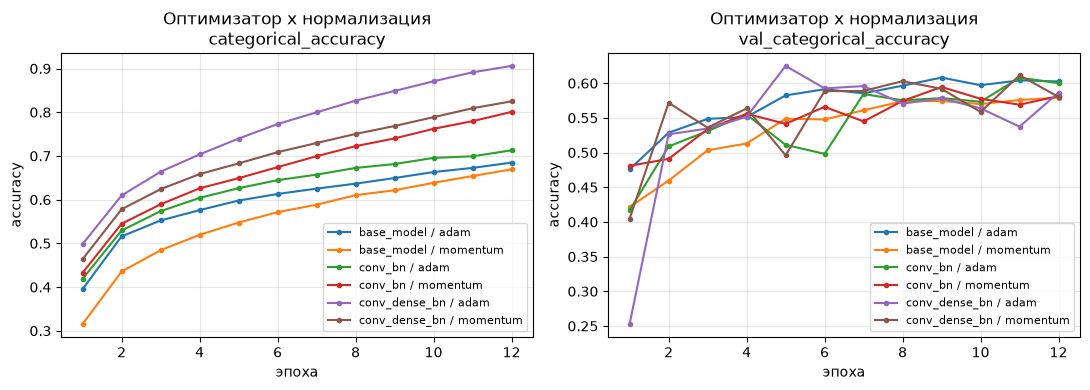

,параметров,лучшая val_accuracy,эпох,разрыв train-val,на 3-й эпохе
base_model / adam,226390.0,0.6081,12.0,0.0823,0.5486
base_model / momentum,226390.0,0.5791,12.0,0.0901,0.5033
conv_bn / adam,226430.0,0.6079,12.0,0.1128,0.5310
conv_bn / momentum,226430.0,0.5945,12.0,0.2193,0.5337
conv_dense_bn / adam,226830.0,0.6249,12.0,0.3195,0.5346
conv_dense_bn / momentum,226830.0,0.6114,12.0,0.2447,0.5359


Лучшая по итогу:       conv_dense_bn / adam
Быстрее всех стартует: base_model / adam
Меньше переобучается:  base_model / adam


In [29]:
evaluator_combo = Evaluator(models, optimizers={
    'adam': tf.keras.optimizers.Adam(learning_rate=0.001),
    'momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
})
evaluator_combo.fit(X_train, y_train, validation_data=(X_val, y_val), max_epochs=12, batch_size=128)

plot_curves(evaluator_combo, 'Оптимизатор x нормализация')
combo_table = table_of(evaluator_combo)
combo_table['разрыв train-val'] = [
    round(m.history.history['categorical_accuracy'][-1] - m.history.history['val_categorical_accuracy'][-1], 4)
    for _, m, _, _ in evaluator_combo]
combo_table['на 3-й эпохе'] = [round(m.history.history['val_categorical_accuracy'][2], 4)
                               for _, m, _, _ in evaluator_combo]
display(combo_table)

print('Лучшая по итогу:      ', combo_table['лучшая val_accuracy'].idxmax())
print('Быстрее всех стартует:', combo_table['на 3-й эпохе'].idxmax())
print('Меньше переобучается: ', combo_table['разрыв train-val'].idxmin())

Лидер по качеству conv_dense_bn с adam (0.6249), но разрыв train-val 0.32. Качество ниже на 1.7 пункта, зато разрыв 0.0823, вчетверо меньше, и старт быстрее всех. Плюс заметил, что adam обгоняет momentum во всех трёх парах, то есть на свёрточных сетях это стабильнее, чем на полносвязной из 1.3.

## Свёрточная нейросеть здорового человека

**Задание 1.7 (обязательно попытаться)** Наигравшись выше, обучим большую свёрточную сеть, которая даст на тестовой выборке __accuracy больше 80%__. В этом задании вам потребуется провести эксперименты, сравнив их между собой в конце. Возможно, может быть несколько проще, если писать выводы во время или сразу после каждого эксперимента, после чего сделать общие выводы.

Рекомендуем начать с лучшей модели предыдущего задания и постепенно её улучшать. Вы можете использовать всё, что угодно: любые активации, сколь угодно большие свёрточные слои и глубокие сети. Единственное ограничение: __нельзя использовать предобученные сети и дополнительные данные__.

### Полезные советы
* Для начала, неплохо бы научить что-нибудь побольше, чем 10 фильтров 3x3.
* __Главное правило: одно изменение на эксперимент__. Если у вас есть 2 идеи по улучшению сети, сначала попробуйте их независимо. Может оказаться, что одно из них дало __+10%__ точности а другое __-7%__. А вы так и будете думать, что сделали 2 полезных изменения которые в сумме дают __+3%__. Если какая-то идея не работает — даже если она вам нравится - опишите ее и выкидывайте из дальнейших экспериментов.
* __Be careful or you will dropout__. Дропаут (`L.Dropout`) может позволить вам обучить в несколько раз бОльшую сеть без переобучения, выжав несколько процентов качества. Это круто, но не стоит сразу ставить dropout 50%. Во-первых, слишком сильный дропаут только ухудшит сеть (underfitting). Во-вторых, даже если дропаут улучшает качество, он замедляет обучение. Рекомендуем начинать с небольшого дропаута, быстро провести основные эксперименты, а потом жахнуть в 2 раза больше нейронов и дропаута ~~на ночь~~.
* __Аугментация данных__. Если котика слегка повернуть и подрезать (простите), он всё равно останется котиком. А в керасе есть [удобный класс](https://keras.io/preprocessing/image/), который поставит подрезание котиков на поток. Ещё можно сделать этот трюк в тесте: вертим картинку 10 раз, предсказываем вероятности и усредняем. Только один совет: прежде, чем учить, посмотрите глазами на аугментированные картинки. Если вы сами не можете их различить, то и сеть не сможет.
* __Don't just stack more layers__. Есть более эффективные способы организовать слои, чем простой Sequential. Вот пара идей: [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions](https://arxiv.org/abs/1608.06993). Только не копируйте архитектуру подчистую — вам скорее всего хватит меньшего размера.
* __Долго != плохо__. Более глубокие архитектуры обычно требуют бОльше эпох до сходимости. Это значит, что в первые несколько эпох они могут быть хуже менее глубоких аналогов. Дайте им время, запаситесь чаем и обмажьтесь batch-norm-ом.

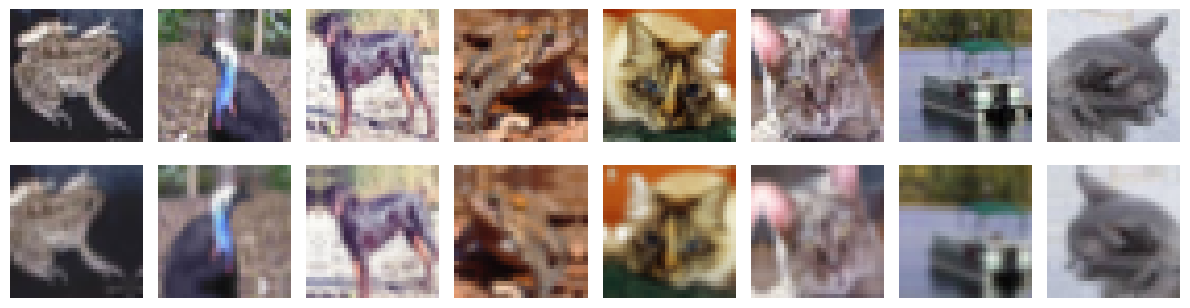

In [30]:
datagen = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(15 / 360),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomFlip('horizontal'),
], name='augmentation')

sample = X_train[:8]
augmented = datagen(sample, training=True).numpy()

plt.figure(figsize=(12, 3.5))
for i in range(8):
    plt.subplot(2, 8, i + 1); plt.imshow(sample[i]); plt.axis('off')
    plt.subplot(2, 8, i + 9); plt.imshow(np.clip(augmented[i], 0, 1)); plt.axis('off')
plt.tight_layout(); plt.show()

In [31]:
dg_x_train, dg_y_train = X_train, y_train
dg_x_val, dg_y_val = X_val, y_val
print('обучение:', len(dg_x_train), '| валидация:', len(dg_x_val))

обучение: 40000 | валидация: 10000


In [32]:
final_model = tf.keras.models.Sequential([tf.keras.layers.Input(shape=(32, 32, 3)), datagen])

for filters, dropout in [(32, 0.2), (64, 0.3), (128, 0.4)]:
    for _ in range(2):
        final_model.add(tf.keras.layers.Conv2D(filters, (3, 3), padding='same', use_bias=False))
        final_model.add(tf.keras.layers.BatchNormalization())
        final_model.add(tf.keras.layers.Activation('relu'))
    final_model.add(tf.keras.layers.MaxPooling2D())
    final_model.add(tf.keras.layers.Dropout(dropout))

final_model.add(tf.keras.layers.GlobalAveragePooling2D())
final_model.add(tf.keras.layers.Dense(256, use_bias=False))
final_model.add(tf.keras.layers.BatchNormalization())
final_model.add(tf.keras.layers.Activation('relu'))
final_model.add(tf.keras.layers.Dropout(0.5))
final_model.add(tf.keras.layers.Dense(10, activation='softmax'))

final_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 324,714 (1.24 MB)

 Trainable params: 323,306 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [33]:
final_callbacks = [tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, monitor='val_accuracy'), tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=6, min_lr=1e-5, monitor='val_accuracy', mode='max'), tf.keras.callbacks.ModelCheckpoint('final_model.keras', save_best_only=True, monitor='val_accuracy')]

In [34]:
tf.keras.utils.plot_model(final_model, '123.png', show_shapes=True);
final_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

history_final = final_model.fit(dg_x_train, dg_y_train, batch_size=128, epochs=40,
                                callbacks=final_callbacks, verbose=2,
                                validation_data=(dg_x_val, dg_y_val))

You must install pydot (`pip install pydot`) for `plot_model` to work.


Epoch 1/40


313/313 - 89s - 283ms/step - accuracy: 0.3464 - loss: 1.8273 - val_accuracy: 0.1724 - val_loss: 2.7606 - learning_rate: 0.0010


Epoch 2/40


313/313 - 83s - 266ms/step - accuracy: 0.4918 - loss: 1.3989 - val_accuracy: 0.4894 - val_loss: 1.4234 - learning_rate: 0.0010


...

313/313 - 84s - 269ms/step - accuracy: 0.8393 - loss: 0.4676 - val_accuracy: 0.8381 - val_loss: 0.4889 - learning_rate: 2.5000e-04


Epoch 39/40


313/313 - 84s - 269ms/step - accuracy: 0.8419 - loss: 0.4621 - val_accuracy: 0.8461 - val_loss: 0.4640 - learning_rate: 2.5000e-04


Epoch 40/40


313/313 - 84s - 269ms/step - accuracy: 0.8424 - loss: 0.4589 - val_accuracy: 0.8406 - val_loss: 0.4797 - learning_rate: 2.5000e-04


Момент истины: проверьте, какого качества достигла ваша сеть.

In [35]:
predict_x=final_model.predict(X_test)
classes_x=np.argmax(predict_x,axis=1)

test_acc = accuracy_score(y_test, classes_x)
print("\n Test_acc =", test_acc)
if test_acc > 0.8:
    print("Это победа!")


  1/313 ━━━━━━━━━━━━━━━━━━━━ 40s 129ms/step


  5/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step  


 10/313 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


 15/313 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


 20/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step

...


305/313 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step



 Test_acc = 0.8387
Это победа!


А теперь, опишите свои <s>ощущения</s> результаты от проведенных экспериментов.

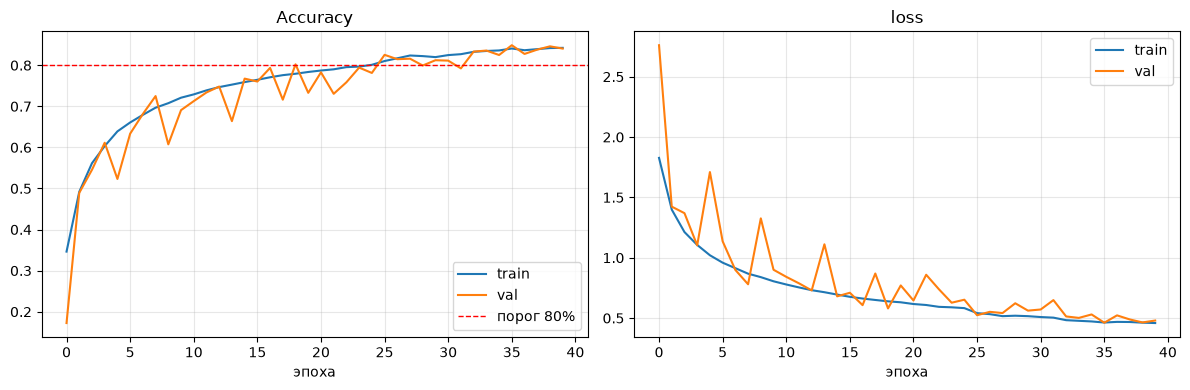

              precision    recall  f1-score   support

    airplane      0.855     0.851     0.853      1000
  automobile      0.911     0.942     0.926      1000
        bird      0.876     0.683     0.767      1000
         cat      0.764     0.646     0.700      1000
        deer      0.815     0.834     0.825      1000
         dog      0.776     0.786     0.781      1000
        frog      0.748     0.955     0.839      1000
       horse      0.909     0.851     0.879      1000
        ship      0.931     0.898     0.914      1000
       truck      0.831     0.941     0.883      1000

    accuracy                          0.839     10000
   macro avg      0.842     0.839     0.837     10000
weighted avg      0.842     0.839     0.837     10000



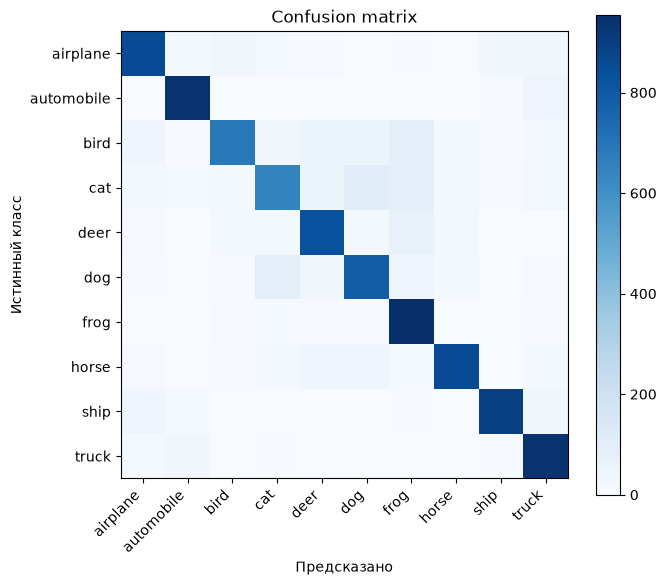

Чаще всего сеть путает "cat" с "dog" — 111 раз


In [36]:
h = history_final.history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(h['accuracy'], label='train'); plt.plot(h['val_accuracy'], label='val')
plt.axhline(0.8, color='red', ls='--', lw=1, label='порог 80%')
plt.title('Accuracy'); plt.xlabel('эпоха'); plt.legend(); plt.grid(alpha=0.3)
plt.subplot(1, 2, 2)
plt.plot(h['loss'], label='train'); plt.plot(h['val_loss'], label='val')
plt.title('loss'); plt.xlabel('эпоха'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(classification_report(y_test, classes_x, target_names=[c.strip() for c in class_names], digits=3))

cm = confusion_matrix(y_test, classes_x)
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.xticks(range(10), [c.strip() for c in class_names], rotation=45, ha='right')
plt.yticks(range(10), [c.strip() for c in class_names])
plt.xlabel('Предсказано'); plt.ylabel('Истинный класс'); plt.title('Confusion matrix')
plt.colorbar(); plt.tight_layout(); plt.show()

np.fill_diagonal(cm, 0)
i, j = np.unravel_index(cm.argmax(), cm.shape)
print(f'Чаще всего сеть путает "{class_names[i].strip()}" с "{class_names[j].strip()}" — {cm[i, j]} раз')

## Выводы

Свёртка работает лучше полносвязной сети, причём заметно. У полносвязной 1.7 млн параметров и 0.5213 на тесте, у карманной свёрточной 226 тысяч параметров и 0.5789. Параметров в 7.5 раз меньше, а качество выше. Дело в том, что Flatten разрушает структуру картинки: для полносвязного слоя соседние пиксели это просто два разных входа. Свёртка же ищет один и тот же узор по всей картинке и переиспользует веса.

BatchNorm на маленькой сети почти ничего не даёт. Без нормализации 0.5992, с нормализацией только после свёртки 0.5890, с нормализацией ещё и в полносвязном слое 0.6174. Разброс тут такой же, как между разными запусками одного и того же кода. Уверенно можно сказать только одно: вариант с BN только после свёртки оказался худшим во всех прогонах. А вот в большой сети из задания 1.7 BatchNorm стоит после каждой свёртки, и там без него обучение просто не сходится.

Batch size это выбор между числом шагов и скоростью эпохи. Батч 32 дошёл до 55 % за 3 эпохи, но потратил 54.6 секунды. Батч 2048 уложился в 19 эпох и 81.3 секунды. Быстрее всех оказался батч 128: 4 эпохи и 28.3 секунды. Интересно, что лучшее качество при этом у батча 32 (0.5889). Мелкий батч даёт шумную оценку градиента, и этот шум помогает выбираться из плохих минимумов.

Переобучение важнее пары пунктов точности. В задании 1.6 лучший результат у conv_dense_bn с adam (0.6249), но у base_model с adam разрыв между train и val всего 0.0823 при качестве 0.6081. В качестве разница маленькая, а запас на дальнейшее обучение у второго варианта больше.

Большая сеть взяла порог: 0.8387 на тесте при требуемых 0.80. Она прошла все 40 эпох, лучшая val_accuracy 0.8488 была на 36-й, то есть сеть росла почти до самого конца. До этого был прогон, где ReduceLROnPlateau с patience 3 следил за val_loss. Из-за аугментации val_loss скачет, расписание срабатывало почти каждые три эпохи, шаг упал в 64 раза и обучение застряло на 0.7901. После смены на val_accuracy с patience 6 сеть доучилась нормально, разница почти пять пунктов.

Хуже всего распознаются bird (полнота 0.683) и cat (0.646), лучше всего automobile (0.942) и ship (0.914). Чаще всего путает кошку с собакой, 111 раз. На картинке 32 на 32 их и человек не всегда различит.